> 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#research-agent>

### 1. Create worker agents

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_core.tools import tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults 

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [3]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[get_web_search],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent",
)

In [4]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [5]:
for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "who is the mayor of NYC?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  get_web_search (0c75d227-b49e-4783-bdf3-251516c45d71)
 Call ID: 0c75d227-b49e-4783-bdf3-251516c45d71
  Args:
    query: mayor of NYC



----- WEB SEARCH -----
mayor of NYC
w
1. snippet: 21 hours ago · An election for the mayor of New York City is scheduled for November 4, 2025. Incumbent Eric Adams, who was elected as a Democrat, is seeking re-election to a second term as an independent. He is being challenged by Democratic state assemblyman Zohran Mamdani, Republican activist Curtis Sliwa, and independent former governor Andrew Cuomo., title: 2025 New York City mayoral election - Wikipedia, link: https://en.wikipedia.org/wiki/2025_New_York_City_mayoral_election
2. snippet: 1 day ago · Track the latest polls about Mamdani, Cuomo, Adams and Sliwa in the New York City mayoral election., title: New York City Mayoral Election 2025: Latest Polls, link

In [6]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

In [7]:
for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "what's (3 + 5) x 7"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (032a359e-72b6-4c26-bbcc-7c2ad8a5a16a)
 Call ID: 032a359e-72b6-4c26-bbcc-7c2ad8a5a16a
  Args:
    b: 5
    a: 3


Update from node tools:


================================= Tool Message =================================
Name: add

8.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (baa20546-8c01-4296-be16-cb39ef135d4d)
 Call ID: baa20546-8c01-4296-be16-cb39ef135d4d
  Args:
    b: 7
    a: 8


Update from node tools:


================================= Tool Message =================================
Name: multiply

56.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent

56




### 2. Create supervisor with langgraph-supervisor

In [8]:
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=init_chat_model("google_genai:gemini-2.5-flash"),
    agents=[research_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

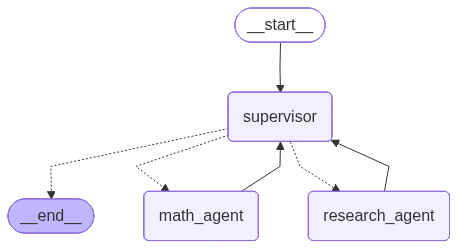

In [12]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

In [ ]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent



----- WEB SEARCH -----
US GDP 2024
w

----- WEB SEARCH -----
New York state GDP 2024
w
1. snippet: Notes: BEA Account Code: A191RC Gross domestic product ( GDP ), the featured measure of U.S . output, is the market value of the goods and services produced by labor and property located in the United States.For more information, see the Guide to the National Income and Product Accounts of the United States (NIPA) and the Bureau of Economic Analysis., title: Gross Domestic Product (GDP) | FRED | St. Louis Fed, link: https://fred.stlouisfed.org/series/GDP/
2. snippet: Gross Domestic Product ( GDP ) measures the annualized change in the inflation-adjusted value of all goods and services produced by the economy., title: United States Gross Domestic Product (GDP) QoQ - Investing.com, link: https://www.in